In [1]:
import sys

sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import pykitti

from pathlib import Path

# Load KITTI
base = Path.home() / 'SensorTrust' / 'datasets' / 'kitti'
data = pykitti.raw(base_path=str(base), date='2011_09_26', drive='0009')

from src.proxies.gps_proxy import extract_all_gps_proxies
from src.proxies.imu_proxy import extract_all_imu_proxies
from src.proxies.camera_proxy import extract_all_camera_proxies
from src.proxies.lidar_proxy import extract_all_lidar_proxies

from src.attacks.imu_attack import (
    constant_bias,
    linear_drift,
    gaussian_noise,
    burst_noise,
    scale_factor_attack,
    attack_imu_proxies
)

from src.attacks.camera_attack import (
    gaussian_noise,
    salt_pepper_noise,
    brightness_shift,
    motion_blur,
    occlusion,
    freeze_frames,
    drop_frames
)

from src.features.normalization import MotionNormalizer
from src.features.f1_kinematic import extract_all_f1_features

print(f"Frames: {len(data.oxts)}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Frames: 447


In [2]:
'''Extract Clean IMU Proxies'''
imu_clean = extract_all_imu_proxies(data.oxts, dt=0.1035)

print(f"   IMU proxies extracted")
print(f"   Keys: {list(imu_clean.keys())}")
print(f"   Frames: {len(imu_clean['yaw_rate'])}")
print(f"   yaw_rate mean: {np.mean(imu_clean['yaw_rate']):.4f} rad/s")
print(f"   delta_v mean:  {np.mean(imu_clean['delta_v']):.4f} m/s")

   IMU proxies extracted
   Keys: ['delta_v', 'yaw_rate']
   Frames: 447
   yaw_rate mean: 0.0279 rad/s
   delta_v mean:  nan m/s


In [3]:
'''Generate All 5 Attacked Versions'''
imu_bias   = attack_imu_proxies(imu_clean, attack_type="bias",  bias=0.05)
imu_drift  = attack_imu_proxies(imu_clean, attack_type="drift", final_bias=0.1)
imu_noise  = attack_imu_proxies(imu_clean, attack_type="noise", std=0.02)
imu_burst  = attack_imu_proxies(imu_clean, attack_type="burst", start_frame=200, duration=30, amplitude=0.3)
imu_scale  = attack_imu_proxies(imu_clean, attack_type="scale", scale=1.2)

all_attacks = {
    "Constant Bias":  imu_bias,
    "Linear Drift":   imu_drift,
    "Gaussian Noise": imu_noise,
    "Burst Noise":    imu_burst,
    "Scale Factor":   imu_scale,
}

colors = ["tomato", "darkorange", "mediumorchid", "dodgerblue", "seagreen"]
attack_names = list(all_attacks.keys())

print(" All 5 attacks generated")
for name, attacked in all_attacks.items():
    diff = np.mean(np.abs(attacked["yaw_rate"] - imu_clean["yaw_rate"]))
    print(f"   {name:<20} | mean |yaw_rate diff|: {diff:.5f}")

 All 5 attacks generated
   Constant Bias        | mean |yaw_rate diff|: 0.05000
   Linear Drift         | mean |yaw_rate diff|: 0.05000
   Gaussian Noise       | mean |yaw_rate diff|: 0.01649
   Burst Noise          | mean |yaw_rate diff|: 0.01810
   Scale Factor         | mean |yaw_rate diff|: 0.00940


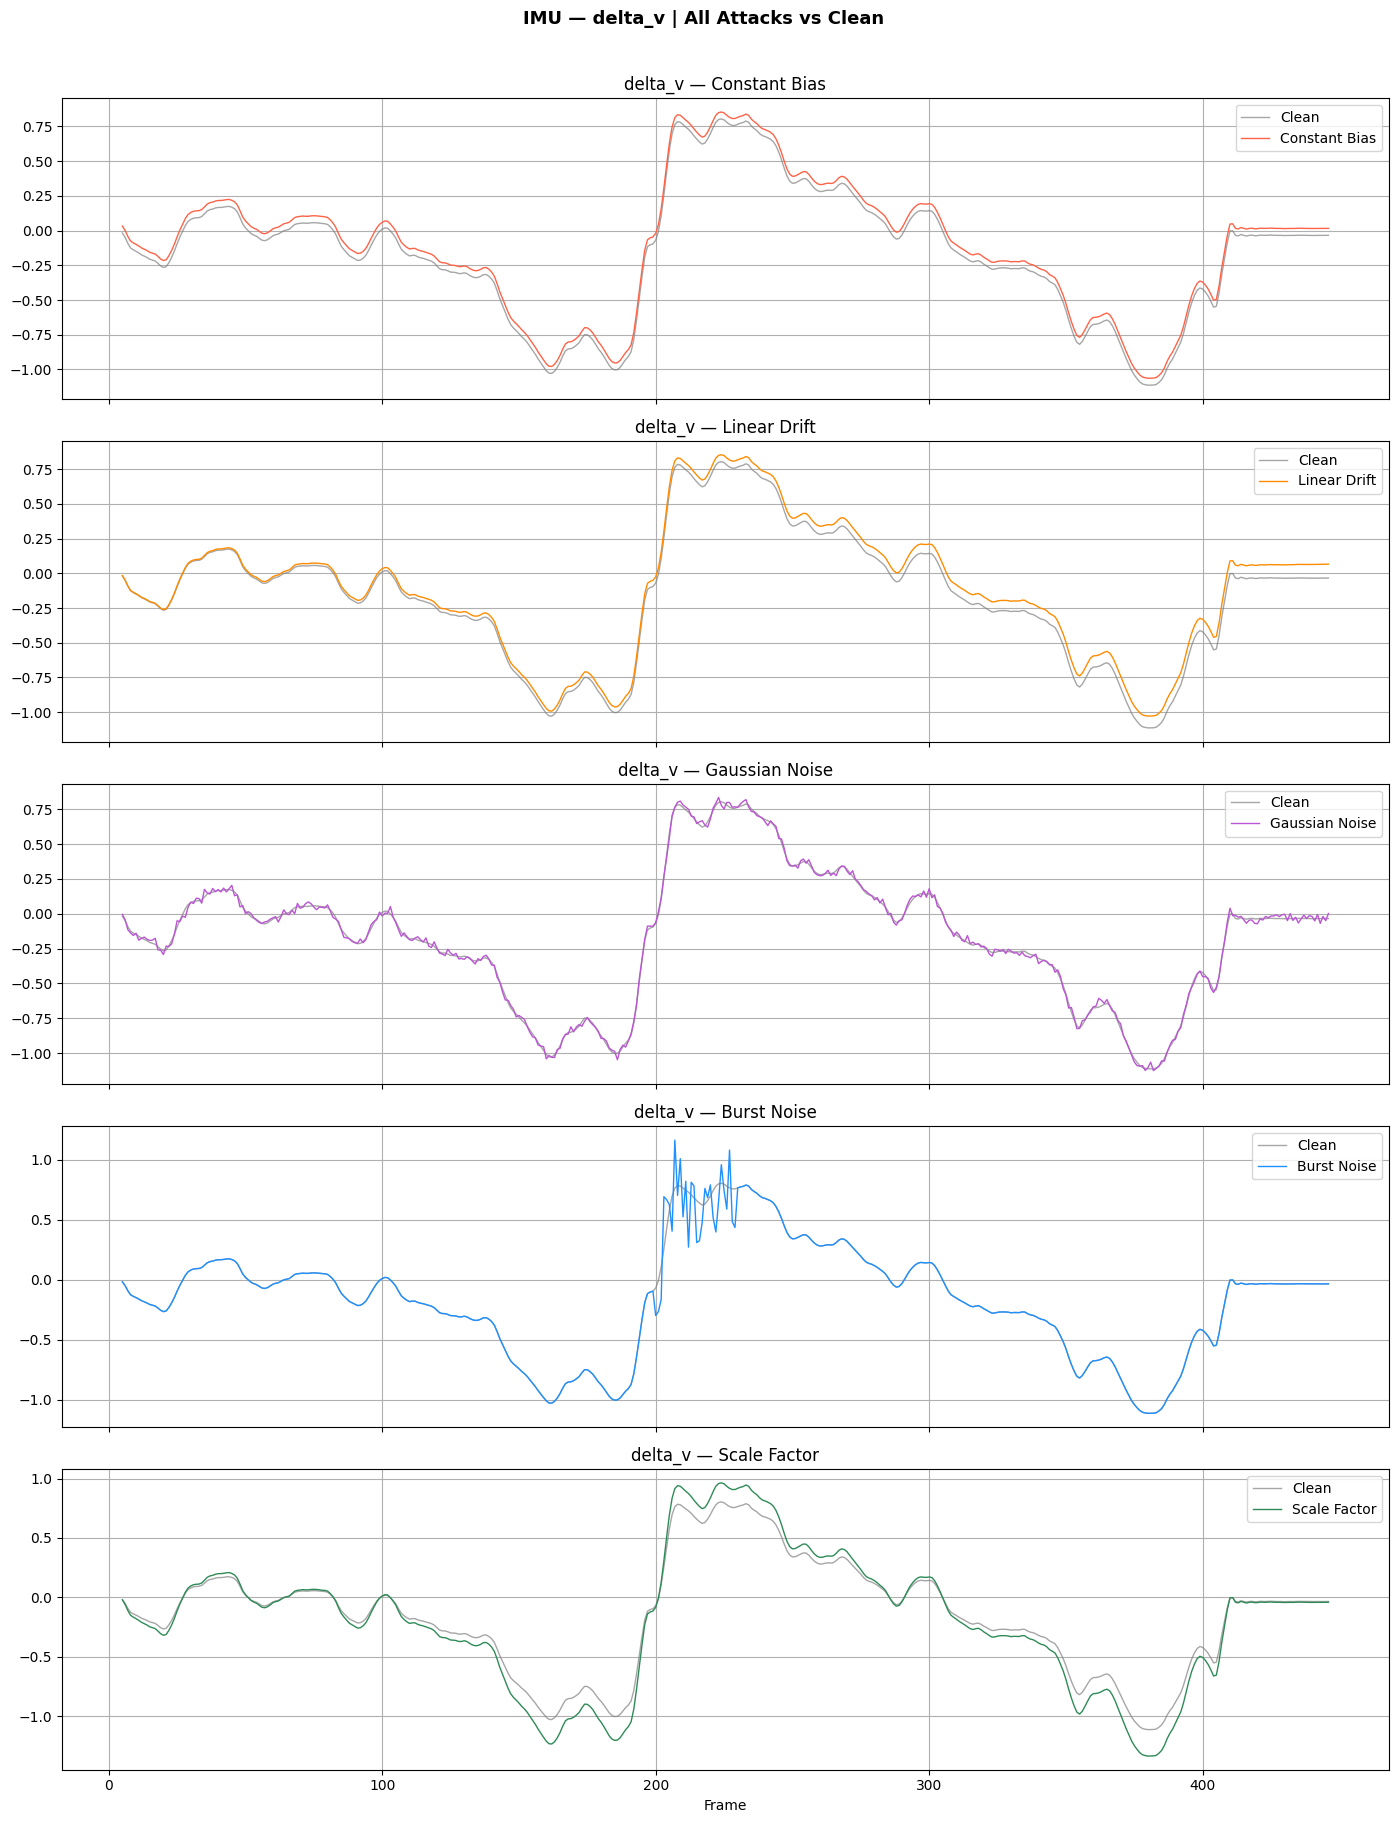

delta_v plotted


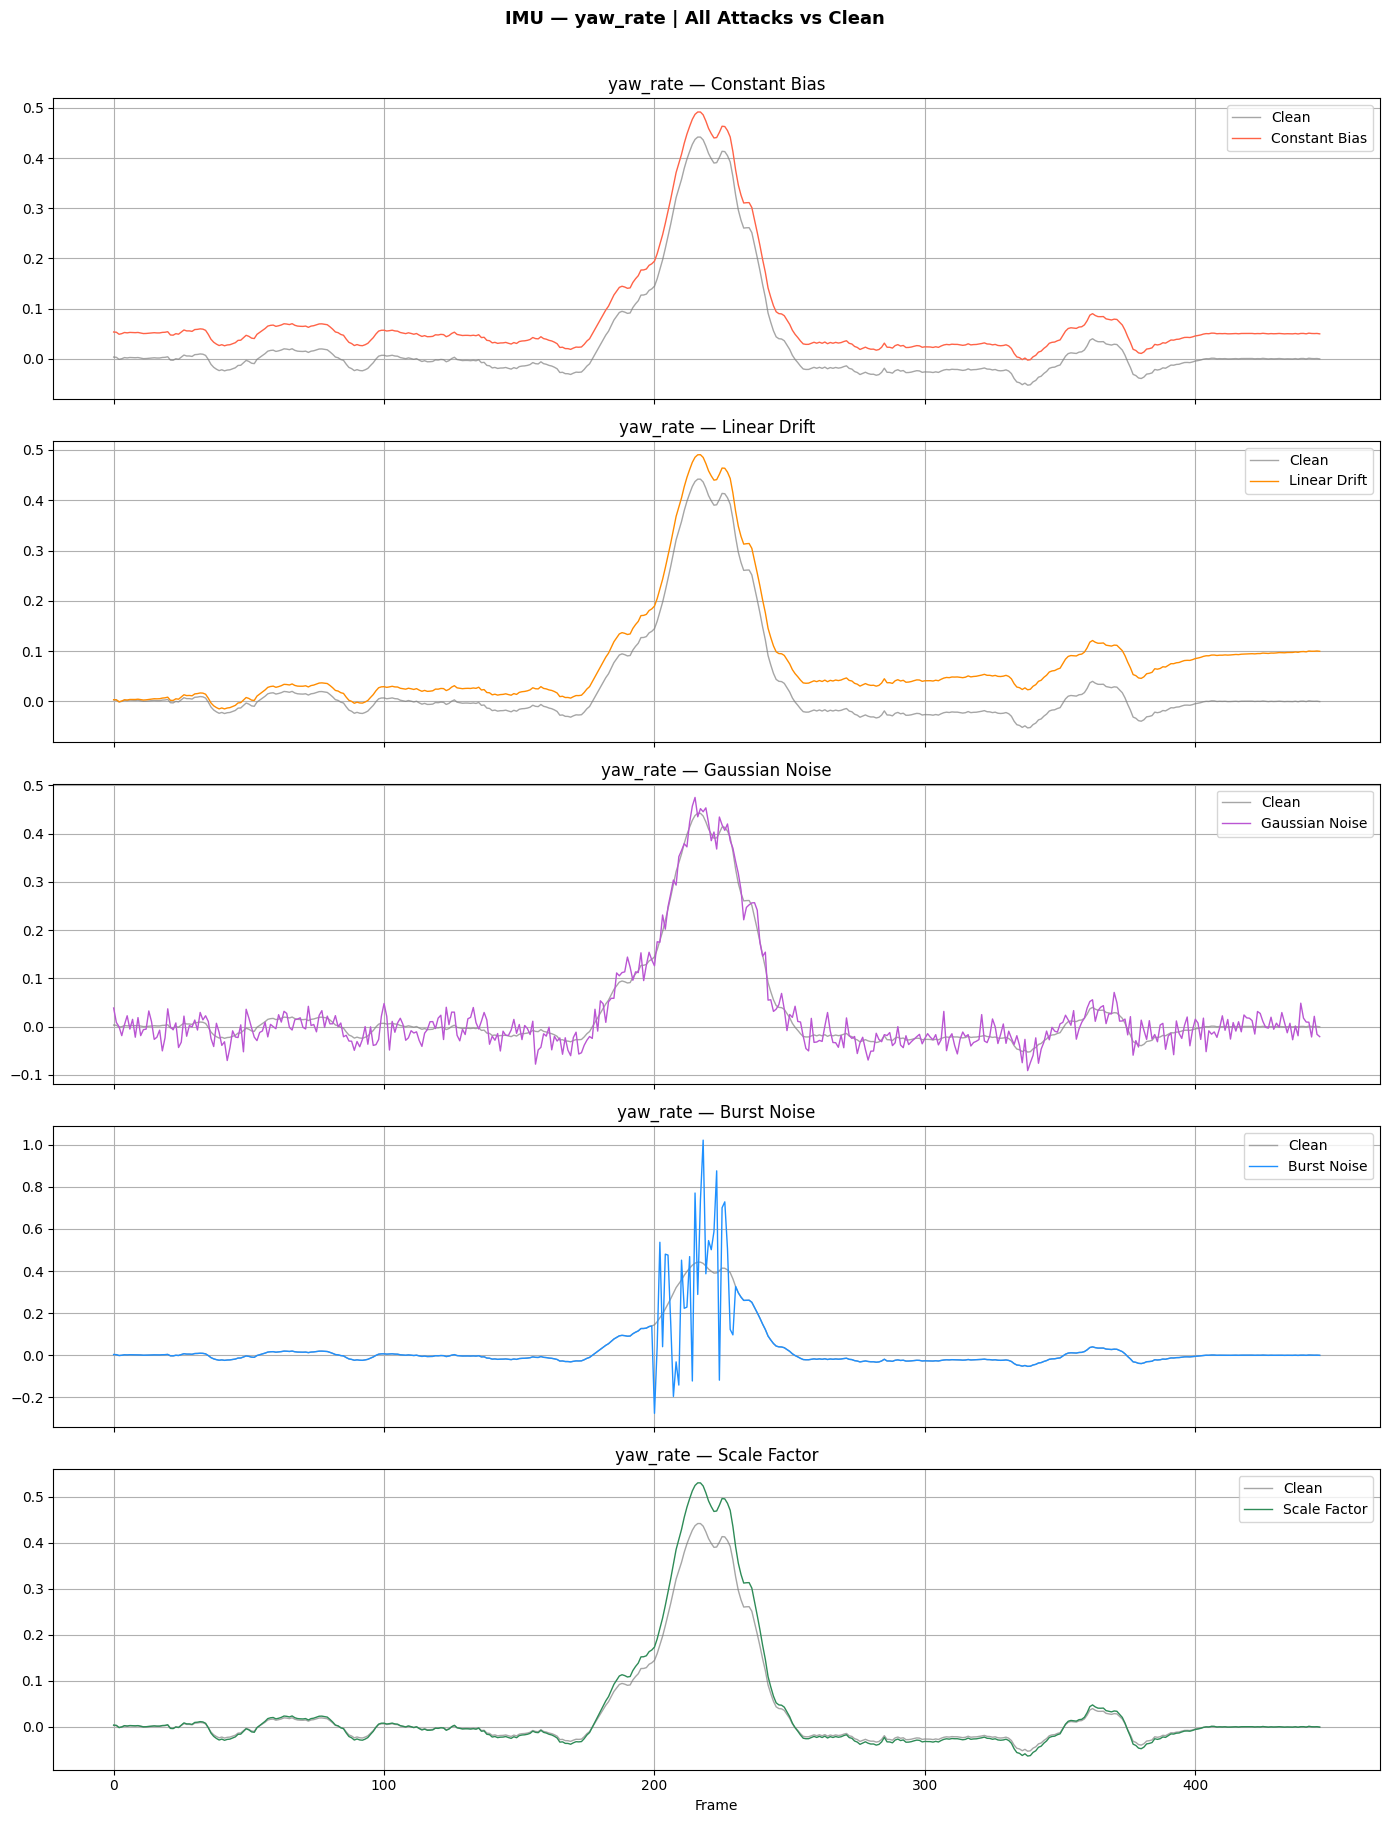

yaw_rate plotted


In [10]:
'''Plot All signals, all attacks'''

for signal_key in imu_clean.keys():
    fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

    for i, (name, attacked) in enumerate(all_attacks.items()):
        axes[i].plot(imu_clean[signal_key], label="Clean", color="gray", linewidth=1, alpha=0.7)
        axes[i].plot(attacked[signal_key],  label=name,    color=colors[i], linewidth=1)
        axes[i].set_title(f"{signal_key} — {name}")
        axes[i].legend(loc="upper right")
        axes[i].grid(True)

    axes[-1].set_xlabel("Frame")
    plt.suptitle(f"IMU — {signal_key} | All Attacks vs Clean", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"{signal_key} plotted")

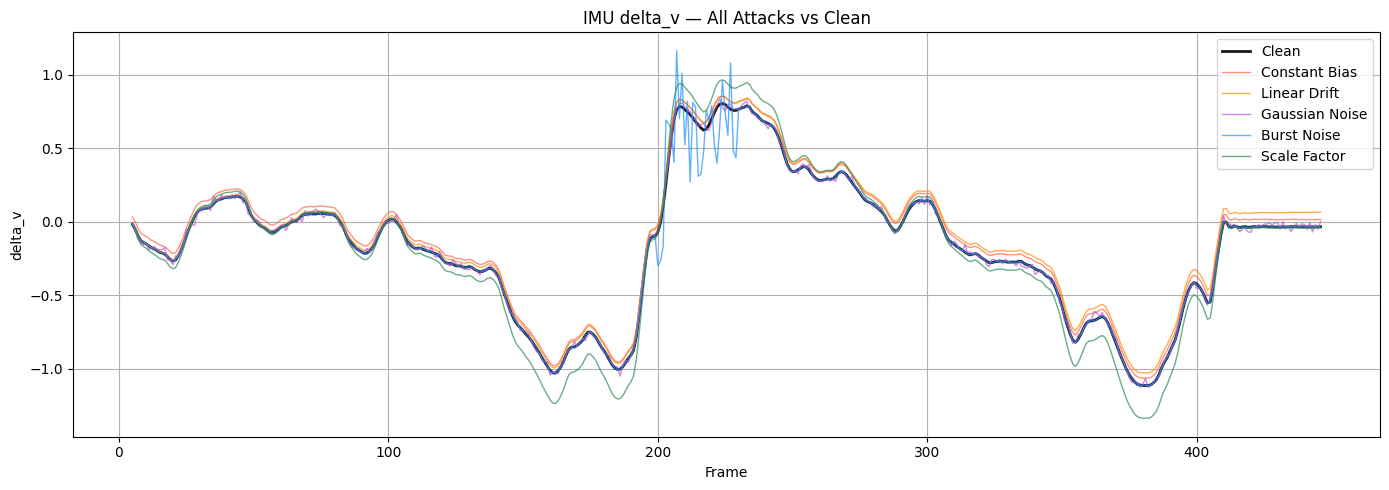

✅ delta_v overlay plotted


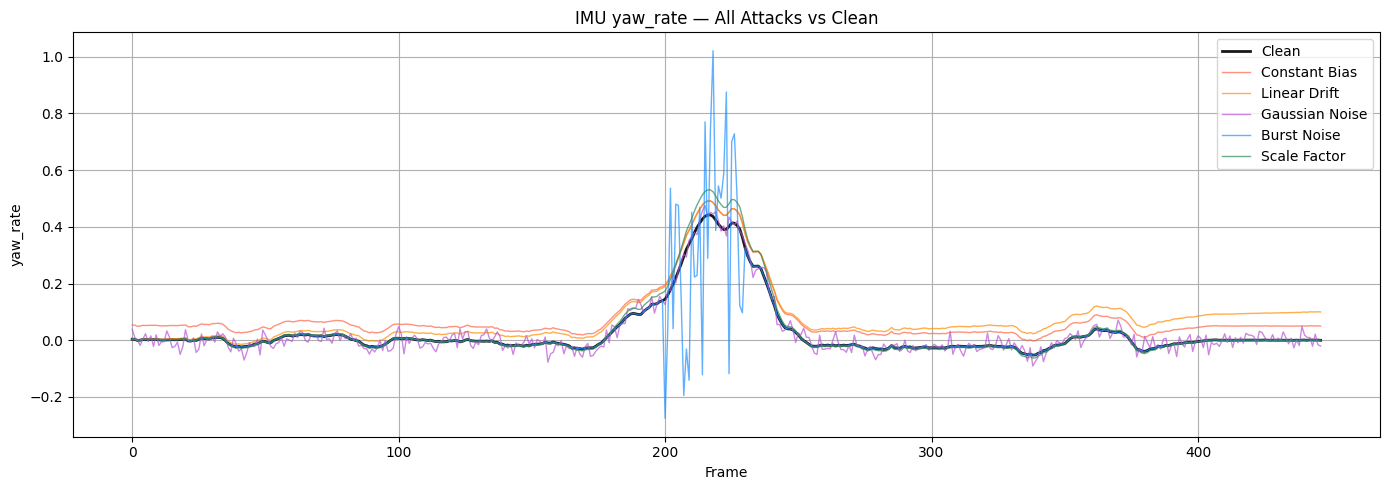

✅ yaw_rate overlay plotted


In [11]:
'''Overlay — all attacks on one plot, per signal'''
for signal_key in imu_clean.keys():
    plt.figure(figsize=(14, 5))
    plt.plot(imu_clean[signal_key], label="Clean", color="black", linewidth=2, alpha=0.9)

    for name, attacked, color in zip(attack_names, all_attacks.values(), colors):
        plt.plot(attacked[signal_key], label=name, color=color, linewidth=1, alpha=0.7)

    plt.title(f"IMU {signal_key} — All Attacks vs Clean")
    plt.xlabel("Frame")
    plt.ylabel(signal_key)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print(f"{signal_key} overlay plotted")

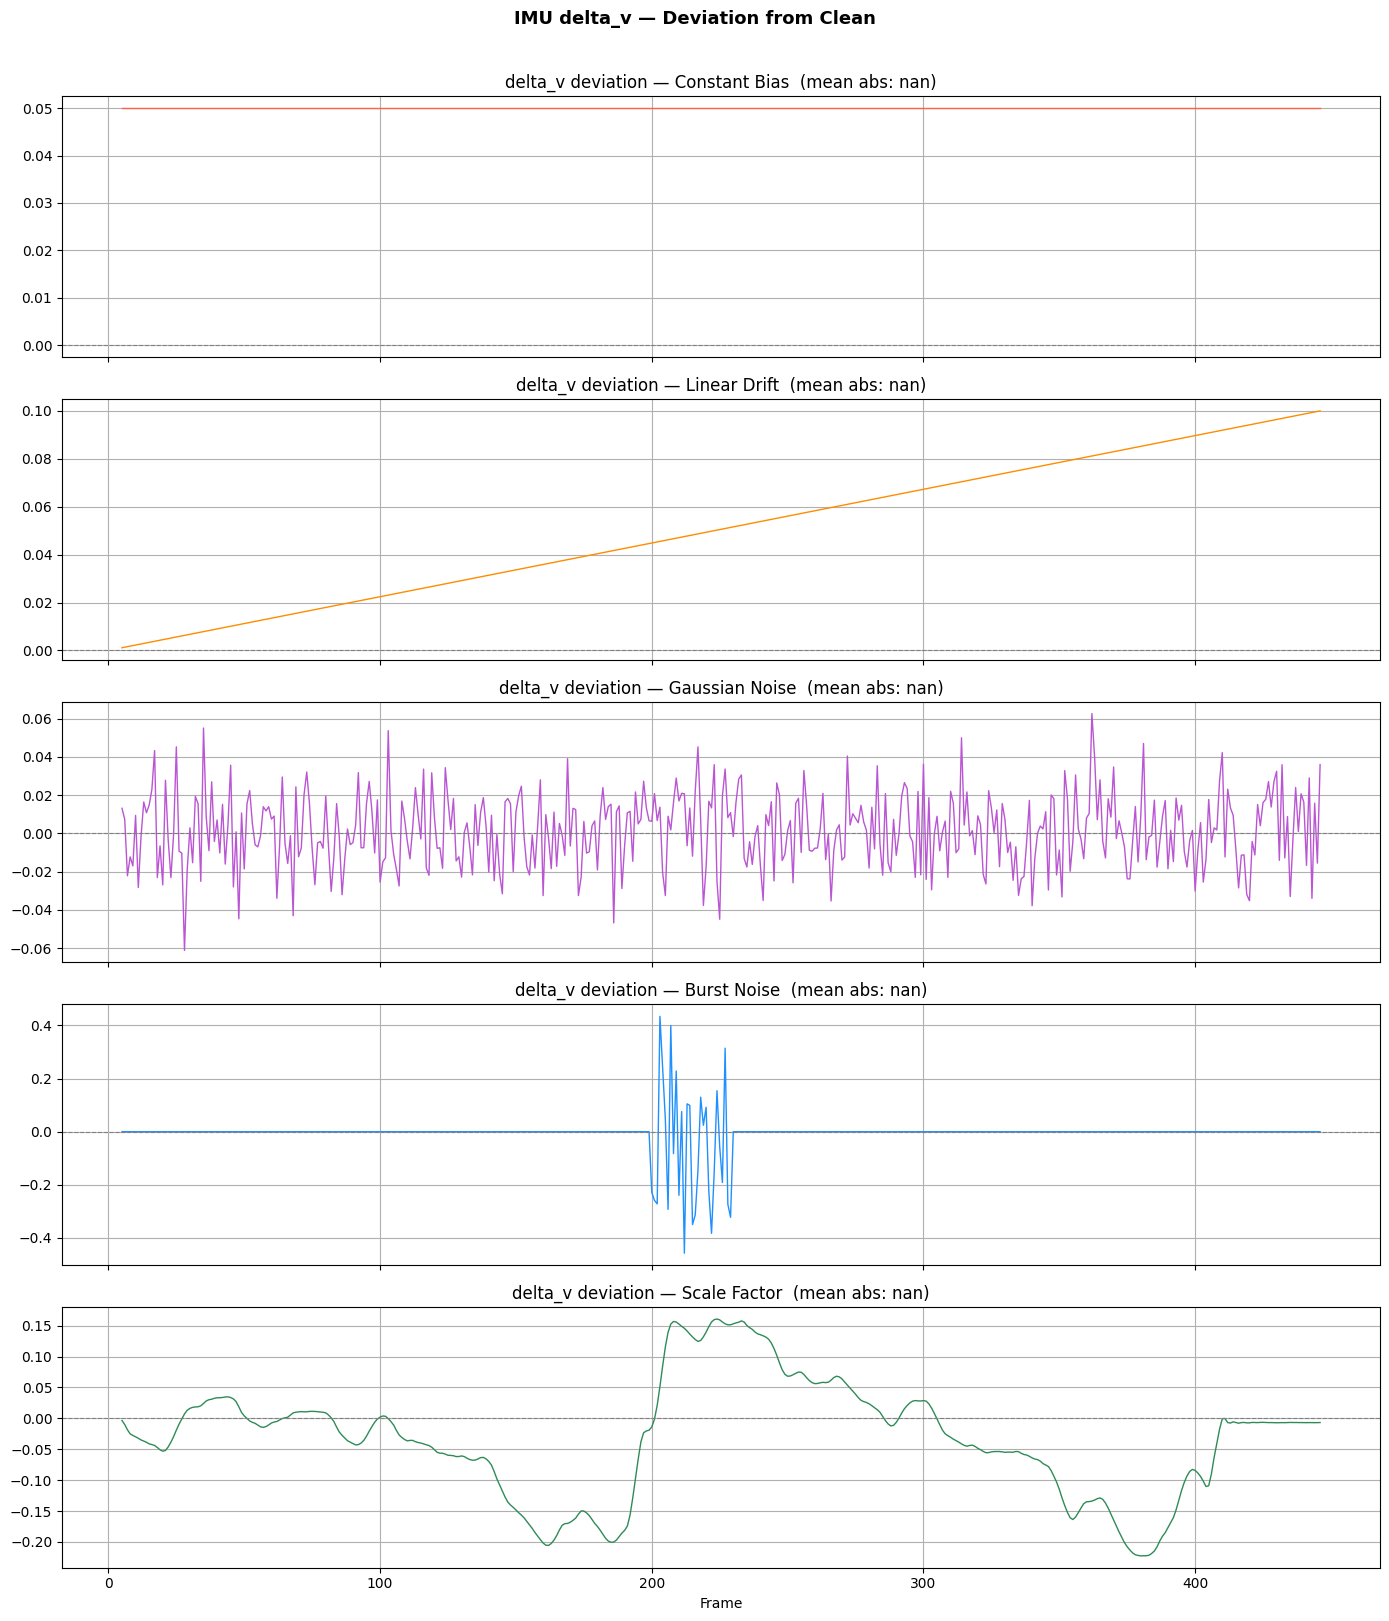

✅ delta_v deviation plotted


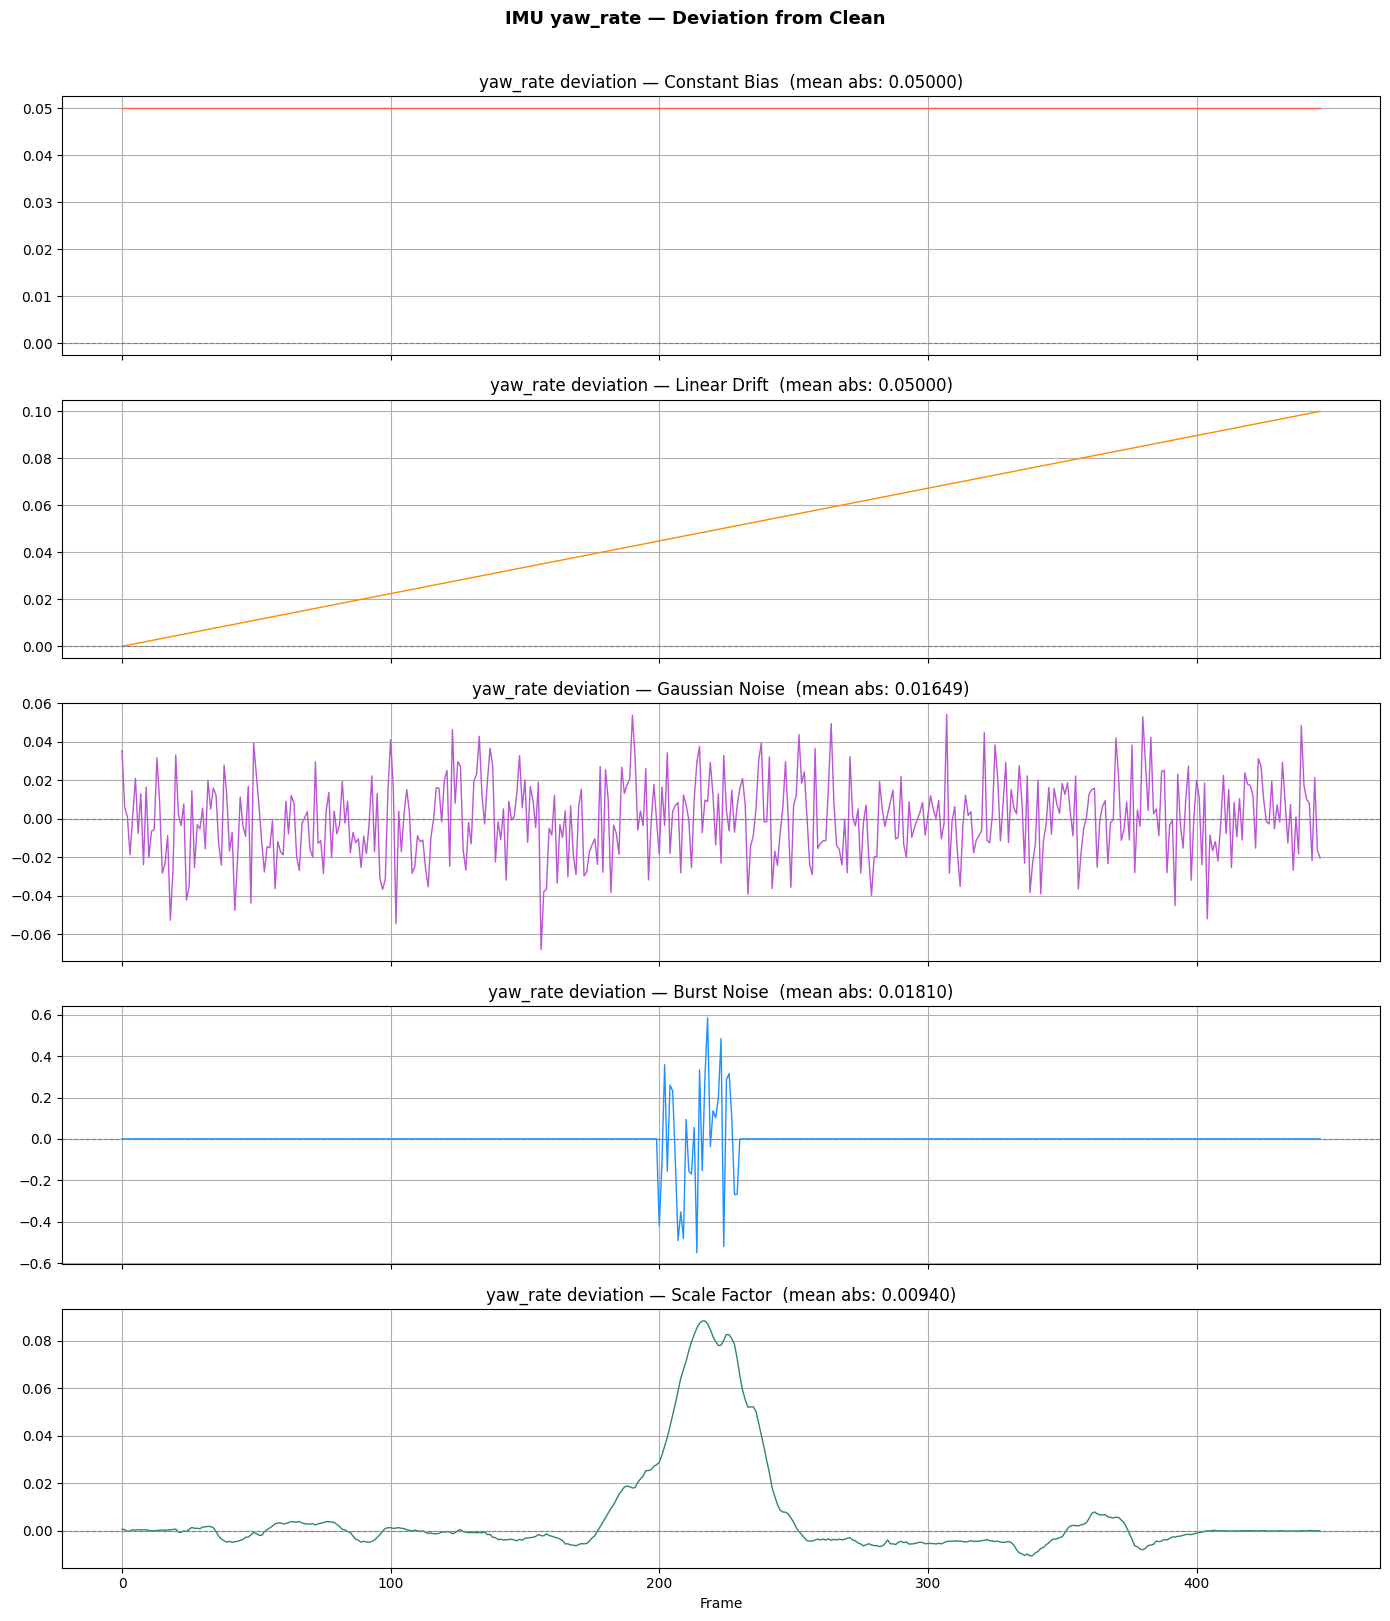

✅ yaw_rate deviation plotted


In [12]:
'''Deviation signals, per signal'''
for signal_key in imu_clean.keys():
    fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

    for i, (name, attacked) in enumerate(all_attacks.items()):
        diff = attacked[signal_key] - imu_clean[signal_key]
        axes[i].plot(diff, color=colors[i], linewidth=1)
        axes[i].axhline(0, color="gray", linestyle="--", linewidth=0.8)
        axes[i].set_title(f"{signal_key} deviation — {name}  (mean abs: {np.mean(np.abs(diff)):.5f})")
        axes[i].grid(True)

    axes[-1].set_xlabel("Frame")
    plt.suptitle(f"IMU {signal_key} — Deviation from Clean", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"{signal_key} deviation plotted")

In [8]:
#Stats Summary Table
print("\nIMU Attack Statistics — yaw_rate\n")
print(f"{'Attack':<20} | {'Mean Diff':>10} | {'Max Diff':>10} | {'Std Diff':>10}")
print("-" * 58)

for name, attacked in all_attacks.items():
    diff = np.abs(attacked["yaw_rate"] - imu_clean["yaw_rate"])
    print(f"{name:<20} | {np.mean(diff):>10.5f} | {np.max(diff):>10.5f} | {np.std(diff):>10.5f}")

print("\nIMU Attack Statistics — delta_v\n")
print(f"{'Attack':<20} | {'Mean Diff':>10} | {'Max Diff':>10} | {'Std Diff':>10}")
print("-" * 58)

for name, attacked in all_attacks.items():
    diff = np.abs(attacked["delta_v"] - imu_clean["delta_v"])
    print(f"{name:<20} | {np.mean(diff):>10.5f} | {np.max(diff):>10.5f} | {np.std(diff):>10.5f}")


📊 IMU Attack Statistics — yaw_rate

Attack               |  Mean Diff |   Max Diff |   Std Diff
----------------------------------------------------------
Constant Bias        |    0.05000 |    0.05000 |    0.00000
Linear Drift         |    0.05000 |    0.10000 |    0.02893
Gaussian Noise       |    0.01649 |    0.06789 |    0.01223
Burst Noise          |    0.01810 |    0.58504 |    0.07870
Scale Factor         |    0.00940 |    0.08840 |    0.01887

📊 IMU Attack Statistics — delta_v

Attack               |  Mean Diff |   Max Diff |   Std Diff
----------------------------------------------------------
Constant Bias        |        nan |        nan |        nan
Linear Drift         |        nan |        nan |        nan
Gaussian Noise       |        nan |        nan |        nan
Burst Noise          |        nan |        nan |        nan
Scale Factor         |        nan |        nan |        nan
